<a href="https://colab.research.google.com/github/prasadreddy9866/Detecting-Fraudulent-Job-Postings/blob/main/Rangam_V_23106062_fake_job_posting_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Fraudulent Job Postings -- RoBERTa Fine-Tuning vs. Naive Bayes

**Dataset:** `victor/real-or-fake-fake-jobposting-prediction` (HuggingFace Hub)
**Deep model:** `roberta-base`, fine-tuned end-to-end
**Reference model:** Multinomial Naive Bayes over bag-of-words counts

## Libraries

In [2]:
!pip install -q transformers datasets shap scikit-learn joblib ipywidgets

In [3]:
import os, re, json, math, time, string, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve

import joblib

plt.style.use("seaborn-v0_8-darkgrid")

In [4]:
def fn_report_runtime_environment():
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU only)"
    print("-" * 60)
    print(f"torch version      : {torch.__version__}")
    print(f"CUDA available      : {torch.cuda.is_available()}")
    print(f"GPU                 : {gpu_name}")
    print(f"pandas version      : {pd.__version__}")
    print("-" * 60)


fn_report_runtime_environment()

------------------------------------------------------------
torch version      : 2.11.0+cu128
CUDA available      : True
GPU                 : Tesla T4
pandas version      : 2.2.2
------------------------------------------------------------


## Configuration Dictionary

In [5]:
JOB_CFG = {
    "data": {
        "hub_id": "victor/real-or-fake-fake-jobposting-prediction",
        "text_fields": ["title", "company_profile", "description", "requirements", "benefits"],
        "label_field_candidates": ["fraudulent", "label", "target"],
        "val_fraction": 0.15,
        "test_fraction": 0.15,
        "max_rows": 12000,
    },
    "text": {
        "lowercase": True,
        "strip_html": True,
        "collapse_whitespace": True,
        "max_token_length_percentile": 97,
        "hard_token_cap": 256,
    },
    "model": {
        "backbone": "roberta-base",
        "num_labels": 2,
        "dropout_override": 0.10,
    },
    "optim": {
        "peak_lr": 1.5e-5,
        "weight_decay": 0.01,
        "warmup_fraction": 0.10,
        "grad_accumulation_steps": 4,
        "micro_batch_size": 8,
        "max_grad_norm": 1.0,
        "num_epochs": 3,
        "eval_every_n_steps": 60,
    },
    "runtime": {
        "seed": 2024,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "artifact_dir": "job_fraud_artifacts",
    },
}

os.makedirs(JOB_CFG["runtime"]["artifact_dir"], exist_ok=True)

In [6]:
def fn_lock_random_state(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


fn_lock_random_state(JOB_CFG["runtime"]["seed"])
print(json.dumps(JOB_CFG, indent=2))

{
  "data": {
    "hub_id": "victor/real-or-fake-fake-jobposting-prediction",
    "text_fields": [
      "title",
      "company_profile",
      "description",
      "requirements",
      "benefits"
    ],
    "label_field_candidates": [
      "fraudulent",
      "label",
      "target"
    ],
    "val_fraction": 0.15,
    "test_fraction": 0.15,
    "max_rows": 12000
  },
  "text": {
    "lowercase": true,
    "strip_html": true,
    "collapse_whitespace": true,
    "max_token_length_percentile": 97,
    "hard_token_cap": 256
  },
  "model": {
    "backbone": "roberta-base",
    "num_labels": 2,
    "dropout_override": 0.1
  },
  "optim": {
    "peak_lr": 1.5e-05,
    "weight_decay": 0.01,
    "warmup_fraction": 0.1,
    "grad_accumulation_steps": 4,
    "micro_batch_size": 8,
    "max_grad_norm": 1.0,
    "num_epochs": 3,
    "eval_every_n_steps": 60
  },
  "runtime": {
    "seed": 2024,
    "device": "cuda",
    "artifact_dir": "job_fraud_artifacts"
  }
}


## Dataset Inspection

In [7]:
def fn_load_raw_dataset(cfg):
    hub_id = cfg["data"]["hub_id"]
    print(f"Fetching dataset '{hub_id}' ...")
    raw = load_dataset(hub_id)
    # Some hub ports only expose a 'train' split; concatenate whatever splits exist.
    frames = [raw[split_name].to_pandas() for split_name in raw.keys()]
    full_df = pd.concat(frames, ignore_index=True)
    cap = cfg["data"]["max_rows"]
    if cap is not None and len(full_df) > cap:
        full_df = full_df.sample(n=cap, random_state=cfg["runtime"]["seed"]).reset_index(drop=True)
    return full_df

In [8]:
def fn_locate_label_column(df, candidates):
    '''Return the first column name (from `candidates`) that actually exists in `df`.'''
    for name in candidates:
        if name in df.columns:
            return name
    raise ValueError(f"None of the candidate label columns {candidates} were found in {list(df.columns)}")

In [9]:
postings_df = fn_load_raw_dataset(JOB_CFG)
LABEL_COL = fn_locate_label_column(postings_df, JOB_CFG["data"]["label_field_candidates"])
postings_df[LABEL_COL] = postings_df[LABEL_COL].astype(int)

Fetching dataset 'victor/real-or-fake-fake-jobposting-prediction' ...


README.md:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

fake_job_postings.csv: reconstructing file:   0%|          |  0.00B / 50.1MB            

fake_job_postings.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/17880 [00:00<?, ? examples/s]

In [10]:
print(f"Resolved label column -> '{LABEL_COL}'")
print(f"Shape: {postings_df.shape}")
postings_df.info()

Resolved label column -> 'fraudulent'
Shape: (12000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               12000 non-null  int64 
 1   title                12000 non-null  object
 2   location             11779 non-null  object
 3   department           4258 non-null   object
 4   salary_range         1938 non-null   object
 5   company_profile      9764 non-null   object
 6   description          11999 non-null  object
 7   requirements         10190 non-null  object
 8   benefits             7153 non-null   object
 9   telecommuting        12000 non-null  int64 
 10  has_company_logo     12000 non-null  int64 
 11  has_questions        12000 non-null  int64 
 12  employment_type      9693 non-null   object
 13  required_experience  7249 non-null   object
 14  required_education   6550 non-null   object
 

In [11]:
def fn_plot_label_balance_donut(df, label_col):
    counts = df[label_col].value_counts().sort_index()
    labels = ["genuine (0)", "fraudulent (1)"]
    colors = ["#3d5a80", "#ee6c4d"]

    fig, ax = plt.subplots(figsize=(5, 5))
    wedges, _, autotexts = ax.pie(
        counts.values, labels=labels, autopct="%1.1f%%", colors=colors,
        startangle=90, pctdistance=0.8,
        wedgeprops=dict(width=0.42, edgecolor="white"),
    )
    ax.set_title("Class balance: genuine vs. fraudulent postings")
    plt.setp(autotexts, size=10, weight="bold", color="white")
    plt.tight_layout()
    plt.show()

    ratio = counts.max() / counts.min()
    print(f"Imbalance ratio (majority/minority): {ratio:.2f} : 1")
    return ratio

In [12]:
def fn_plot_missing_values(df):
    '''Horizontal bar chart of missing-value counts per column, sorted descending.'''
    missing = df.isnull().sum().sort_values(ascending=True)
    missing = missing[missing > 0]
    if missing.empty:
        print("No missing values detected in any column.")
        return
    plt.figure(figsize=(7, 0.35 * len(missing) + 1))
    plt.barh(missing.index.astype(str), missing.values, color="#98c1d9")
    plt.xlabel("missing count")
    plt.title("Missing values per column")
    plt.tight_layout()
    plt.show()

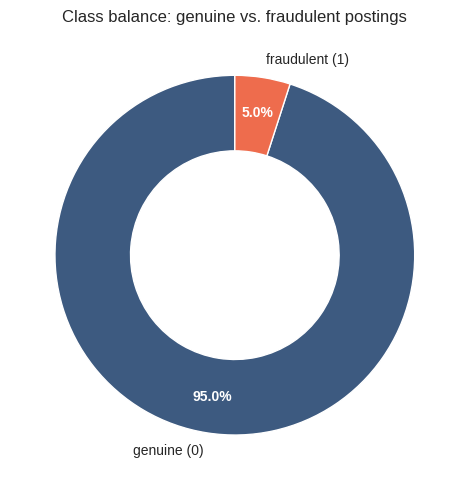

Imbalance ratio (majority/minority): 19.13 : 1


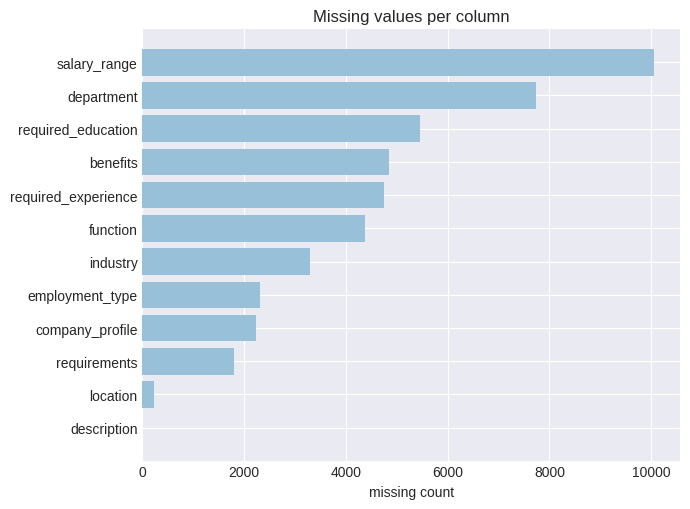

In [13]:
IMBALANCE_RATIO = fn_plot_label_balance_donut(postings_df, LABEL_COL)
fn_plot_missing_values(postings_df)

In [14]:
DUPLICATE_ROWS = postings_df.duplicated().sum()
print(f"Exact duplicate rows: {DUPLICATE_ROWS}")

Exact duplicate rows: 0


## Feature Engineering

In [15]:
def fn_safe_text_column(df, column_name):
    '''Return a column as a string Series, substituting '' for missing columns/values.'''
    if column_name not in df.columns:
        return pd.Series([""] * len(df), index=df.index)
    return df[column_name].fillna("").astype(str)

In [16]:
def fn_engineer_numeric_signals(df, cfg):
    '''
    Build a small DataFrame of hand-crafted numeric "red flag" features.
    Returned as its own frame (not mutating `df`) so callers decide how
    to merge it.
    '''
    combined_text = pd.Series([""] * len(df), index=df.index)
    for field in cfg["data"]["text_fields"]:
        combined_text = combined_text + " " + fn_safe_text_column(df, field)

    char_len = combined_text.str.len()
    word_len = combined_text.str.split().apply(len)
    upper_ratio = combined_text.apply(lambda s: sum(1 for ch in s if ch.isupper()) / max(len(s), 1))
    punct_ratio = combined_text.apply(lambda s: sum(1 for ch in s if ch in string.punctuation) / max(len(s), 1))
    has_url = combined_text.str.contains(r"http[s]?://|www\.", regex=True).astype(int)
    has_money_symbol = combined_text.str.contains(r"[$\u20ac\u00a3]", regex=True).astype(int)
    missing_profile = (fn_safe_text_column(df, "company_profile").str.strip() == "").astype(int)
    missing_requirements = (fn_safe_text_column(df, "requirements").str.strip() == "").astype(int)

    features = pd.DataFrame({
        "char_length": char_len,
        "word_length": word_len,
        "upper_ratio": upper_ratio,
        "punct_ratio": punct_ratio,
        "has_url": has_url,
        "has_money_symbol": has_money_symbol,
        "missing_profile": missing_profile,
        "missing_requirements": missing_requirements,
    })
    return features, combined_text

In [17]:
engineered_df, raw_combined_text = fn_engineer_numeric_signals(postings_df, JOB_CFG)
postings_df = pd.concat([postings_df, engineered_df], axis=1)
postings_df["combined_text"] = raw_combined_text
engineered_df.describe().T

,count,mean,std,min,25%,50%,75%,max
char_length,12000.0,2663.616000,1458.679709,19.000000,1585.000000,2524.500000,3473.000000,13496.000000
word_length,12000.0,373.706167,206.306695,2.000000,228.000000,349.000000,492.000000,2001.000000
upper_ratio,12000.0,0.038160,0.023797,0.003486,0.025157,0.032243,0.044405,0.877193
punct_ratio,12000.0,0.025086,0.009722,0.000000,0.019086,0.023278,0.028415,0.264290
has_url,12000.0,0.008333,0.090910,0.000000,0.000000,0.000000,0.000000,1.000000
has_money_symbol,12000.0,0.189167,0.391657,0.000000,0.000000,0.000000,0.000000,1.000000
missing_profile,12000.0,0.186333,0.389392,0.000000,0.000000,0.000000,0.000000,1.000000
missing_requirements,12000.0,0.151000,0.358064,0.000000,0.000000,0.000000,0.000000,1.000000


In [18]:
def fn_plot_feature_vs_label(df, feature_name, label_col):
    '''Violin plot of a single engineered feature, split by class -- repeated for a small grid.'''
    plt.figure(figsize=(5, 3.5))
    sns.violinplot(data=df, x=label_col, y=feature_name, palette=["#3d5a80", "#ee6c4d"], cut=0)
    plt.xticks([0, 1], ["genuine", "fraudulent"])
    plt.title(f"{feature_name} by class")
    plt.tight_layout()
    plt.show()

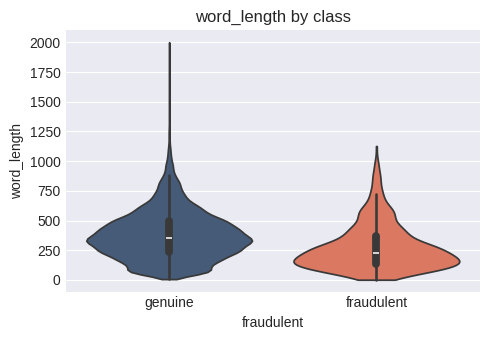

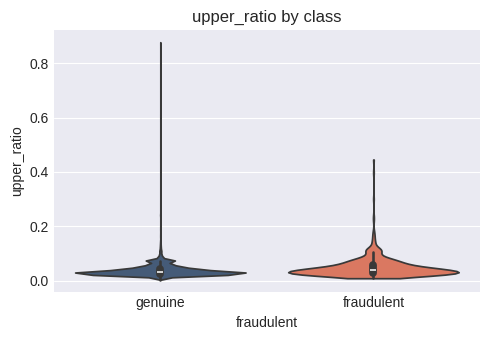

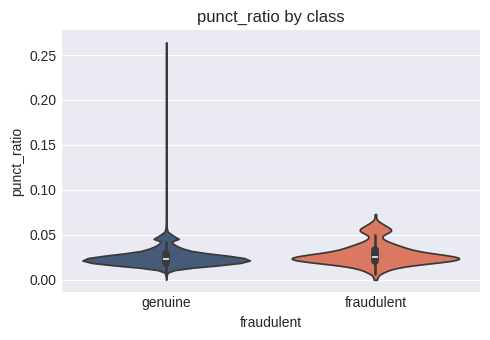

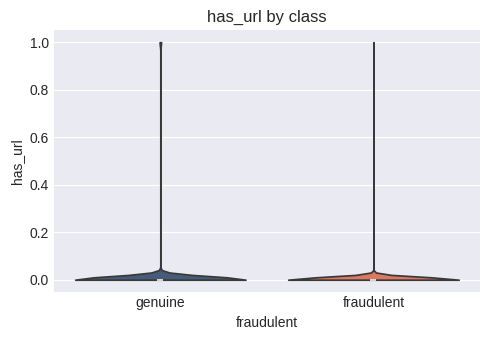

In [19]:
for feature_name in ["word_length", "upper_ratio", "punct_ratio", "has_url"]:
    fn_plot_feature_vs_label(postings_df, feature_name, LABEL_COL)
    print()

In [20]:
def fn_plot_engineered_correlation(df, feature_cols):
    '''Correlation heatmap across the engineered numeric features (diverging colormap).'''
    corr = df[feature_cols].corr()
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Correlation among engineered features")
    plt.tight_layout()
    plt.show()

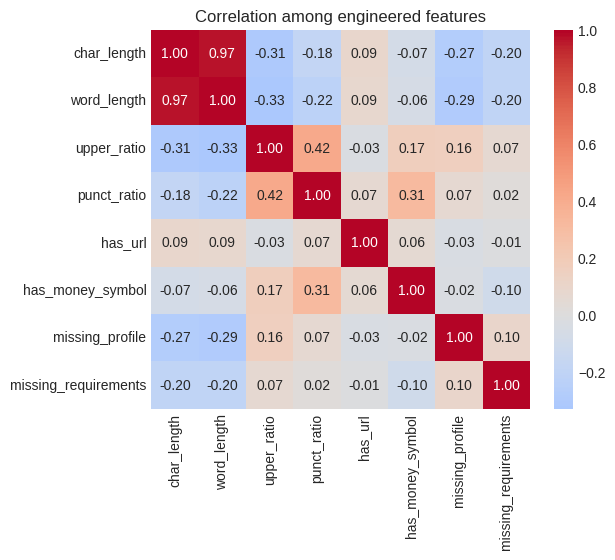

In [21]:
fn_plot_engineered_correlation(postings_df, list(engineered_df.columns))

## Text Cleaning

In [22]:
def fn_strip_html_tags(text):
    '''Remove HTML tags (job postings frequently contain <p>, <li>, <br/> markup).'''
    return re.sub(r"<[^>]+>", " ", text)

In [23]:
def fn_strip_urls(text):
    '''Replace URLs with a neutral placeholder token.'''
    return re.sub(r"http[s]?://\S+|www\.\S+", " URLTOKEN ", text)

In [24]:
def fn_collapse_whitespace(text):
    '''Collapse runs of whitespace/newlines/tabs into single spaces.'''
    return re.sub(r"\s+", " ", text).strip()

In [25]:
def fn_lowercase(text):
    '''Lowercase the full string.'''
    return text.lower()

In [26]:
def fn_compose(*funcs):
    '''Right-to-left function composition: fn_compose(f, g)(x) == f(g(x)).'''
    def _composed(x):
        for fn in reversed(funcs):
            x = fn(x)
        return x
    return _composed

In [27]:
CLEAN_TEXT_PIPELINE = fn_compose(fn_collapse_whitespace, fn_lowercase, fn_strip_urls, fn_strip_html_tags)

In [28]:
postings_df["clean_text"] = postings_df["combined_text"].apply(CLEAN_TEXT_PIPELINE)

In [29]:
print("Cleaning example:")
print("  RAW  :", postings_df["combined_text"].iloc[0][:180])
print("  CLEAN:", postings_df["clean_text"].iloc[0][:180])

Cleaning example:
  RAW  :  Director of Operations  About From the FarmerWe are a fast-growing e-retailer of local foods (grown, raised, or produced within a couple hours drive of our customers) with operati
  CLEAN: director of operations about from the farmerwe are a fast-growing e-retailer of local foods (grown, raised, or produced within a couple hours drive of our customers) with operation


## Reference Model -- Multinomial Naive Bayes

In [30]:
def fn_train_naive_bayes(texts_train, labels_train, alpha=0.5):
    '''Fit CountVectorizer + MultinomialNB and return both fitted objects.'''
    vectorizer = CountVectorizer(max_features=25000, ngram_range=(1, 2), stop_words="english")
    X_train = vectorizer.fit_transform(texts_train)
    classifier = MultinomialNB(alpha=alpha)
    classifier.fit(X_train, labels_train)
    return vectorizer, classifier

In [31]:
def fn_score_naive_bayes(vectorizer, classifier, texts, labels):
    '''Return a metrics dict + raw probability array for a fitted Naive Bayes model.'''
    X = vectorizer.transform(texts)
    probs = classifier.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)
    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs),
    }
    return metrics, probs

## Tokenizer

In [32]:
job_tokenizer = AutoTokenizer.from_pretrained(JOB_CFG["model"]["backbone"])
print(f"Loaded tokenizer for {JOB_CFG['model']['backbone']} | vocab size = {job_tokenizer.vocab_size}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded tokenizer for roberta-base | vocab size = 50265


In [33]:
def fn_recommend_token_budget(texts, tokenizer, cfg, sample_size=2500):
    '''Pick max_length from the empirical token-count distribution rather than guessing.'''
    sample = texts if len(texts) <= sample_size else texts.sample(sample_size, random_state=cfg["runtime"]["seed"])
    token_counts = sample.apply(lambda t: len(tokenizer.encode(t, add_special_tokens=True)))
    pct = cfg["text"]["max_token_length_percentile"]
    raw_budget = int(np.percentile(token_counts, pct))
    budget = min(raw_budget, cfg["text"]["hard_token_cap"])
    return budget, token_counts.values

In [34]:
TOKEN_BUDGET, token_count_sample = fn_recommend_token_budget(postings_df["clean_text"], job_tokenizer, JOB_CFG)
print(f"Selected token budget (max_length) = {TOKEN_BUDGET}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (762 > 512). Running this sequence through the model will result in indexing errors


Selected token budget (max_length) = 256


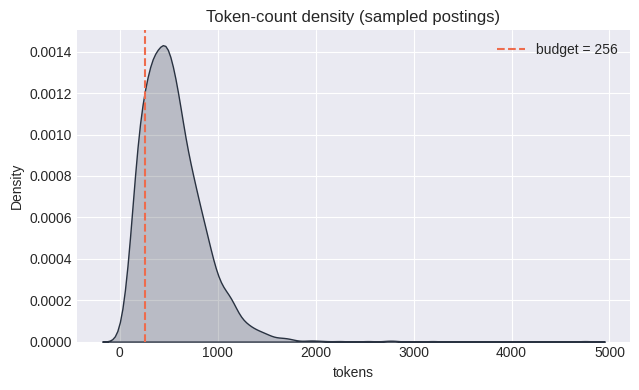

In [35]:
plt.figure(figsize=(6.5, 4))
sns.kdeplot(token_count_sample, fill=True, color="#293241")
plt.axvline(TOKEN_BUDGET, color="#ee6c4d", linestyle="--", label=f"budget = {TOKEN_BUDGET}")
plt.title("Token-count density (sampled postings)")
plt.xlabel("tokens")
plt.legend()
plt.tight_layout()
plt.show()

## Custom Collator

In [36]:
def fn_tokenize_examples(texts, labels, tokenizer, max_len):
    '''Tokenize (truncate-only) every example, returning a plain list[dict].'''
    records = []
    for text, label in zip(texts, labels):
        enc = tokenizer(text, truncation=True, max_length=max_len, add_special_tokens=True)
        records.append({
            "input_ids": enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "label": int(label),
        })
    return records

In [37]:
def fn_dynamic_pad_collate(batch, pad_token_id):
    '''
    Pad every sequence in `batch` up to the longest sequence *in that
    batch*. Returns a dict of stacked tensors ready for the model.
    '''
    longest = max(len(item["input_ids"]) for item in batch)

    padded_ids, padded_mask, labels = [], [], []
    for item in batch:
        pad_amount = longest - len(item["input_ids"])
        padded_ids.append(item["input_ids"] + [pad_token_id] * pad_amount)
        padded_mask.append(item["attention_mask"] + [0] * pad_amount)
        labels.append(item["label"])

    return {
        "input_ids": torch.tensor(padded_ids, dtype=torch.long),
        "attention_mask": torch.tensor(padded_mask, dtype=torch.long),
        "label": torch.tensor(labels, dtype=torch.long),
    }

## RoBERTa Fine-Tuning -- Model Construction

In [38]:
def fn_build_sequence_classifier(cfg):
    '''Instantiate roberta-base for binary sequence classification.'''
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg["model"]["backbone"],
        num_labels=cfg["model"]["num_labels"],
        hidden_dropout_prob=cfg["model"]["dropout_override"],
    )
    return model.to(cfg["runtime"]["device"])

In [39]:
job_model = fn_build_sequence_classifier(JOB_CFG)
total_params = sum(p.numel() for p in job_model.parameters())
print(f"roberta-base loaded on {JOB_CFG['runtime']['device']} | total parameters: {total_params:,}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


roberta-base loaded on cuda | total parameters: 124,647,170


## Weighted Cross Entropy

In [40]:
def fn_compute_inverse_frequency_weights(labels, num_classes):
    '''weight[c] = N / (num_classes * count[c])  -- standard inverse-frequency weighting.'''
    counts = np.bincount(labels, minlength=num_classes)
    counts = np.clip(counts, 1, None)  # avoid div-by-zero for an absent class
    weights = len(labels) / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float)

In [41]:
def fn_make_weighted_loss(weights, device):
    '''Return a ready-to-call CrossEntropyLoss bound to the given class weights.'''
    weighted_loss_fn = nn.CrossEntropyLoss(weight=weights.to(device))
    return weighted_loss_fn

## Validation Strategy

In [42]:
def fn_stratified_three_way_split(df, label_col, cfg):
    '''Carve train/val/test out of `df`, stratified on `label_col` at every step.'''
    val_frac, test_frac = cfg["data"]["val_fraction"], cfg["data"]["test_fraction"]
    seed = cfg["runtime"]["seed"]

    train_part, holdout_part = train_test_split(
        df, test_size=(val_frac + test_frac), stratify=df[label_col], random_state=seed,
    )
    relative_test_frac = test_frac / (val_frac + test_frac)
    val_part, test_part = train_test_split(
        holdout_part, test_size=relative_test_frac, stratify=holdout_part[label_col], random_state=seed,
    )
    return (
        train_part.reset_index(drop=True),
        val_part.reset_index(drop=True),
        test_part.reset_index(drop=True),
    )

In [43]:
train_split, val_split, test_split = fn_stratified_three_way_split(postings_df, LABEL_COL, JOB_CFG)
print(f"train={len(train_split)}  val={len(val_split)}  test={len(test_split)}")
for name, part in [("train", train_split), ("val", val_split), ("test", test_split)]:
    rate = part[LABEL_COL].mean()
    print(f"  {name}: fraud rate = {rate:.3%}")

train=8400  val=1800  test=1800
  train: fraud rate = 4.964%
  val: fraud rate = 5.000%
  test: fraud rate = 4.944%


## Learning Rate Warmup

In [44]:
def fn_make_warmup_cosine_lambda(num_warmup_steps, num_total_steps):
    '''
    Returns a function step -> lr_multiplier suitable for LambdaLR:
      - linear ramp 0 -> 1 over the warmup window
      - cosine decay 1 -> 0 over the remaining steps
    '''
    def _lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return current_step / max(1, num_warmup_steps)
        progress = (current_step - num_warmup_steps) / max(1, num_total_steps - num_warmup_steps)
        progress = min(progress, 1.0)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return _lr_lambda

In [45]:
NUM_OPTIMIZER_STEPS_PER_EPOCH = math.ceil(
    len(train_split) / (JOB_CFG["optim"]["micro_batch_size"] * JOB_CFG["optim"]["grad_accumulation_steps"])
)
TOTAL_OPTIMIZER_STEPS = NUM_OPTIMIZER_STEPS_PER_EPOCH * JOB_CFG["optim"]["num_epochs"]
WARMUP_STEPS = int(JOB_CFG["optim"]["warmup_fraction"] * TOTAL_OPTIMIZER_STEPS)

In [46]:
print(f"optimizer steps/epoch = {NUM_OPTIMIZER_STEPS_PER_EPOCH}, total = {TOTAL_OPTIMIZER_STEPS}, warmup = {WARMUP_STEPS}")

optimizer steps/epoch = 263, total = 789, warmup = 78


In [47]:
job_optimizer = torch.optim.AdamW(
    job_model.parameters(), lr=JOB_CFG["optim"]["peak_lr"], weight_decay=JOB_CFG["optim"]["weight_decay"],
)

In [48]:
job_scheduler = torch.optim.lr_scheduler.LambdaLR(
    job_optimizer, lr_lambda=fn_make_warmup_cosine_lambda(WARMUP_STEPS, TOTAL_OPTIMIZER_STEPS),
)

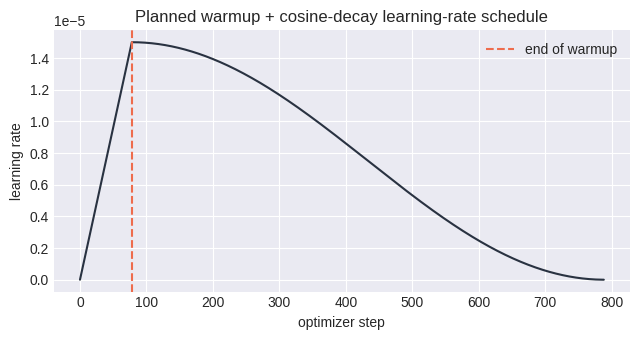

In [49]:
_preview_lrs = [
    JOB_CFG["optim"]["peak_lr"] * fn_make_warmup_cosine_lambda(WARMUP_STEPS, TOTAL_OPTIMIZER_STEPS)(s)
    for s in range(TOTAL_OPTIMIZER_STEPS)
]
plt.figure(figsize=(6.5, 3.5))
plt.plot(_preview_lrs, color="#293241")
plt.axvline(WARMUP_STEPS, color="#ee6c4d", linestyle="--", label="end of warmup")
plt.title("Planned warmup + cosine-decay learning-rate schedule")
plt.xlabel("optimizer step"); plt.ylabel("learning rate")
plt.legend()
plt.tight_layout()
plt.show()

## Gradient Accumulation

In [50]:
def fn_should_step(micro_batch_index, accumulation_steps, is_last_batch_in_epoch):
    '''True exactly on optimizer-update boundaries: every N micro-batches, or on the final one.'''
    reached_accumulation_window = (micro_batch_index + 1) % accumulation_steps == 0
    return reached_accumulation_window or is_last_batch_in_epoch

In [51]:
EFFECTIVE_BATCH_SIZE = JOB_CFG["optim"]["micro_batch_size"] * JOB_CFG["optim"]["grad_accumulation_steps"]
print(f"micro_batch_size={JOB_CFG['optim']['micro_batch_size']}  "
      f"accumulation_steps={JOB_CFG['optim']['grad_accumulation_steps']}  "
      f"=> effective_batch_size={EFFECTIVE_BATCH_SIZE}")

micro_batch_size=8  accumulation_steps=4  => effective_batch_size=32


## Model Selection -- Training Loop & Checkpoint Choice

In [52]:
def fn_records_to_loader(records, cfg, tokenizer, shuffle):
    '''Wrap a list[dict] of tokenized records in a DataLoader with dynamic padding.'''
    batch_size = cfg["optim"]["micro_batch_size"]
    collate = lambda batch: fn_dynamic_pad_collate(batch, tokenizer.pad_token_id)
    return DataLoader(records, batch_size=batch_size, shuffle=shuffle, collate_fn=collate)

In [53]:
def fn_quick_validation_pass(model, loader, device):
    '''Lightweight validation: returns (mean_loss, roc_auc) without any plotting side effects.'''
    model.eval()
    all_probs, all_labels, running_loss, seen = [], [], 0.0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = F.cross_entropy(outputs.logits, labels)
            probs = F.softmax(outputs.logits, dim=-1)[:, 1]
            running_loss += loss.item() * labels.size(0)
            seen += labels.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    auc_score = roc_auc_score(all_labels, all_probs)
    model.train()
    return running_loss / seen, auc_score

In [54]:
def fn_run_training_loop(model, cfg, train_records, val_records, tokenizer, loss_fn, optimizer, scheduler):
    '''
    Custom step-based training loop:
      - micro-batches accumulate gradients for `grad_accumulation_steps` steps
      - optimizer/scheduler only advance on accumulation boundaries
      - validation + checkpointing happen every `eval_every_n_steps` optimizer updates
    Returns a history dict used for the training-curve plots below.
    '''
    device = cfg["runtime"]["device"]
    train_loader = fn_records_to_loader(train_records, cfg, tokenizer, shuffle=True)
    val_loader = fn_records_to_loader(val_records, cfg, tokenizer, shuffle=False)

    best_auc_so_far = -1.0
    optimizer_step_counter = 0
    history = {"step": [], "train_loss": [], "lr": [], "val_step": [], "val_loss": [], "val_auc": []}
    checkpoint_path = os.path.join(cfg["runtime"]["artifact_dir"], "best_roberta_state.pt")

    accumulation_steps = cfg["optim"]["grad_accumulation_steps"]
    running_micro_loss = 0.0

    model.train()
    for epoch_index in range(cfg["optim"]["num_epochs"]):
        num_batches = len(train_loader)
        for micro_idx, batch in enumerate(train_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels) / accumulation_steps
            loss.backward()
            running_micro_loss += loss.item()

            is_last_in_epoch = (micro_idx == num_batches - 1)
            if fn_should_step(micro_idx, accumulation_steps, is_last_in_epoch):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["optim"]["max_grad_norm"])
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                optimizer_step_counter += 1

                history["step"].append(optimizer_step_counter)
                history["train_loss"].append(running_micro_loss)
                history["lr"].append(scheduler.get_last_lr()[0])
                running_micro_loss = 0.0

                if optimizer_step_counter % cfg["optim"]["eval_every_n_steps"] == 0:
                    val_loss, val_auc = fn_quick_validation_pass(model, val_loader, device)
                    history["val_step"].append(optimizer_step_counter)
                    history["val_loss"].append(val_loss)
                    history["val_auc"].append(val_auc)
                    print(f"[epoch {epoch_index+1}] step {optimizer_step_counter}: "
                          f"val_loss={val_loss:.4f} val_auc={val_auc:.4f}")
                    if val_auc > best_auc_so_far:
                        best_auc_so_far = val_auc
                        torch.save(model.state_dict(), checkpoint_path)
                        print(f"    -> new best AUC {val_auc:.4f}; checkpoint saved.")

        print(f"=== epoch {epoch_index+1}/{cfg['optim']['num_epochs']} complete ===")

    model.load_state_dict(torch.load(checkpoint_path))
    print(f"Best validation AUC observed: {best_auc_so_far:.4f} -- weights reloaded from checkpoint.")
    return history, checkpoint_path

In [55]:
train_records = fn_tokenize_examples(train_split["clean_text"], train_split[LABEL_COL], job_tokenizer, TOKEN_BUDGET)
val_records   = fn_tokenize_examples(val_split["clean_text"],   val_split[LABEL_COL],   job_tokenizer, TOKEN_BUDGET)
test_records  = fn_tokenize_examples(test_split["clean_text"],  test_split[LABEL_COL],  job_tokenizer, TOKEN_BUDGET)

In [56]:
class_weights = fn_compute_inverse_frequency_weights(train_split[LABEL_COL].values, JOB_CFG["model"]["num_labels"])
weighted_ce_loss = fn_make_weighted_loss(class_weights, JOB_CFG["runtime"]["device"])
print("Class weights (inverse-frequency):", class_weights.tolist())

Class weights (inverse-frequency): [0.5261179804801941, 10.071942329406738]


In [58]:
training_history, best_checkpoint_path = fn_run_training_loop(
    job_model, JOB_CFG, train_records, val_records, job_tokenizer,
    weighted_ce_loss, job_optimizer, job_scheduler,
)

[epoch 1] step 60: val_loss=0.0708 val_auc=0.9815
    -> new best AUC 0.9815; checkpoint saved.
[epoch 1] step 120: val_loss=0.0708 val_auc=0.9815
[epoch 1] step 180: val_loss=0.0708 val_auc=0.9815
[epoch 1] step 240: val_loss=0.0708 val_auc=0.9815
=== epoch 1/3 complete ===
[epoch 2] step 300: val_loss=0.0708 val_auc=0.9815
[epoch 2] step 360: val_loss=0.0708 val_auc=0.9815
[epoch 2] step 420: val_loss=0.0708 val_auc=0.9815
[epoch 2] step 480: val_loss=0.0708 val_auc=0.9815
=== epoch 2/3 complete ===
[epoch 3] step 540: val_loss=0.0708 val_auc=0.9815
[epoch 3] step 600: val_loss=0.0708 val_auc=0.9815
[epoch 3] step 660: val_loss=0.0708 val_auc=0.9815
[epoch 3] step 720: val_loss=0.0708 val_auc=0.9815
[epoch 3] step 780: val_loss=0.0708 val_auc=0.9815
=== epoch 3/3 complete ===
Best validation AUC observed: 0.9815 -- weights reloaded from checkpoint.


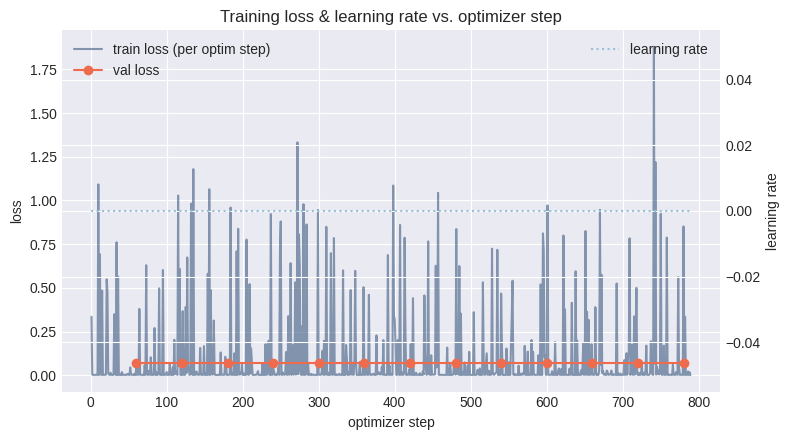

In [59]:
fig, ax_loss = plt.subplots(figsize=(8, 4.5))
ax_loss.plot(training_history["step"], training_history["train_loss"], color="#3d5a80", alpha=0.6, label="train loss (per optim step)")
ax_loss.plot(training_history["val_step"], training_history["val_loss"], color="#ee6c4d", marker="o", label="val loss")
ax_loss.set_xlabel("optimizer step")
ax_loss.set_ylabel("loss")
ax_loss.legend(loc="upper left")

ax_lr = ax_loss.twinx()
ax_lr.plot(training_history["step"], training_history["lr"], color="#98c1d9", linestyle=":", label="learning rate")
ax_lr.set_ylabel("learning rate")
ax_lr.legend(loc="upper right")

plt.title("Training loss & learning rate vs. optimizer step")
plt.tight_layout()
plt.show()

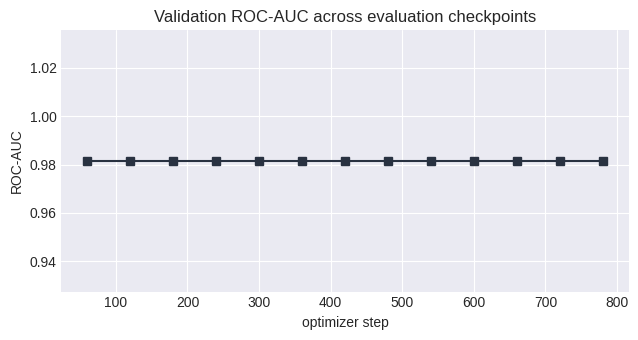

In [60]:
plt.figure(figsize=(6.5, 3.5))
plt.plot(training_history["val_step"], training_history["val_auc"], color="#293241", marker="s")
plt.title("Validation ROC-AUC across evaluation checkpoints")
plt.xlabel("optimizer step"); plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

In [61]:
# Fit the Naive Bayes reference on the same stratified split used for RoBERTa.
nb_vectorizer, nb_classifier = fn_train_naive_bayes(train_split["clean_text"], train_split[LABEL_COL])
nb_test_metrics, nb_test_probs = fn_score_naive_bayes(nb_vectorizer, nb_classifier, test_split["clean_text"], test_split[LABEL_COL])
print("Naive Bayes baseline (held-out test split):")
print(json.dumps(nb_test_metrics, indent=2))

Naive Bayes baseline (held-out test split):
{
  "accuracy": 0.9494444444444444,
  "precision": 0.4931506849315068,
  "recall": 0.8089887640449438,
  "f1": 0.6127659574468085,
  "roc_auc": 0.9668765883674045
}


## Performance Metrics

In [62]:
def fn_score_transformer(model, records, cfg, tokenizer):
    '''Run one inference pass and return (metrics_dict, probs_array, labels_array).'''
    loader = fn_records_to_loader(records, cfg, tokenizer, shuffle=False)
    device = cfg["runtime"]["device"]
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs = F.softmax(logits, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["label"].numpy())
    all_probs, all_labels = np.array(all_probs), np.array(all_labels)
    preds = (all_probs >= 0.5).astype(int)
    metrics = {
        "accuracy": accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall": recall_score(all_labels, preds, zero_division=0),
        "f1": f1_score(all_labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(all_labels, all_probs),
    }
    return metrics, all_probs, all_labels

In [63]:
roberta_test_metrics, roberta_test_probs, roberta_test_labels = fn_score_transformer(
    job_model, test_records, JOB_CFG, job_tokenizer,
)

In [64]:
metric_comparison = pd.DataFrame({"naive_bayes": nb_test_metrics, "roberta_finetuned": roberta_test_metrics}).T
metric_comparison["auc_gain_over_nb"] = metric_comparison["roc_auc"] - metric_comparison.loc["naive_bayes", "roc_auc"]
display(metric_comparison.round(4))

,accuracy,precision,recall,f1,roc_auc,auc_gain_over_nb
naive_bayes,0.9494,0.4932,0.8090,0.6128,0.9669,0.000
roberta_finetuned,0.9850,0.8974,0.7865,0.8383,0.9649,-0.002


## Confusion Matrix

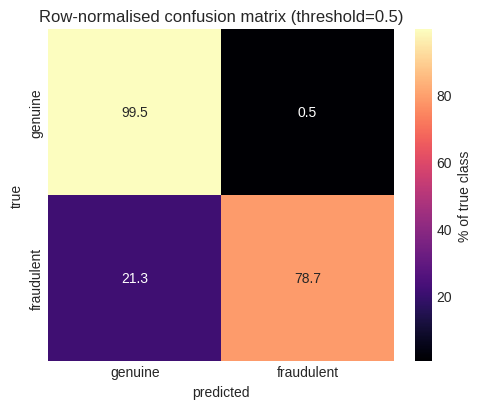

In [65]:
def fn_plot_normalized_confusion(labels, probs, threshold=0.5, class_names=("genuine", "fraudulent")):
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(5, 4.2))
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="magma", cbar_kws={"label": "% of true class"},
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Row-normalised confusion matrix (threshold={threshold})")
    plt.xlabel("predicted"); plt.ylabel("true")
    plt.tight_layout()
    plt.show()
    return cm


_ = fn_plot_normalized_confusion(roberta_test_labels, roberta_test_probs)

## ROC Curve

In [66]:
def fn_plot_roc_overlay(label_arrays, prob_arrays, model_names, colors):
    plt.figure(figsize=(6, 5))
    for labels, probs, name, color in zip(label_arrays, prob_arrays, model_names, colors):
        fpr, tpr, _ = roc_curve(labels, probs)
        score = roc_auc_score(labels, probs)
        plt.plot(fpr, tpr, color=color, label=f"{name} (AUC={score:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance")
    plt.title("ROC curve: RoBERTa vs. Naive Bayes")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

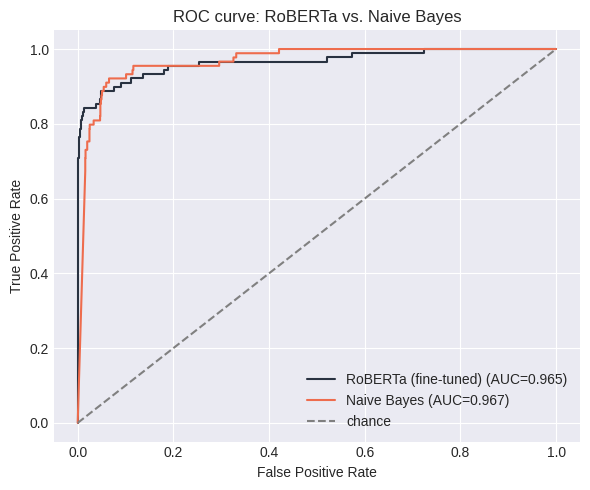

In [67]:
fn_plot_roc_overlay(
    [roberta_test_labels, test_split[LABEL_COL].values],
    [roberta_test_probs, nb_test_probs],
    ["RoBERTa (fine-tuned)", "Naive Bayes"],
    ["#293241", "#ee6c4d"],
)

## Precision-Recall Curve

In [68]:
def fn_plot_pr_overlay(label_arrays, prob_arrays, model_names, colors):
    plt.figure(figsize=(6, 5))
    for labels, probs, name, color in zip(label_arrays, prob_arrays, model_names, colors):
        precision, recall, _ = precision_recall_curve(labels, probs)
        ap = average_precision_score(labels, probs)
        plt.plot(recall, precision, color=color, label=f"{name} (AP={ap:.3f})")
    plt.title("Precision-Recall curve: RoBERTa vs. Naive Bayes")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    plt.show()

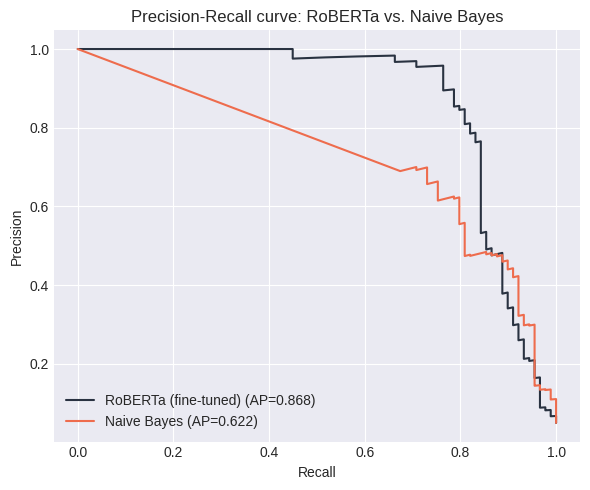

In [69]:
fn_plot_pr_overlay(
    [roberta_test_labels, test_split[LABEL_COL].values],
    [roberta_test_probs, nb_test_probs],
    ["RoBERTa (fine-tuned)", "Naive Bayes"],
    ["#293241", "#ee6c4d"],
)

## Calibration Curve

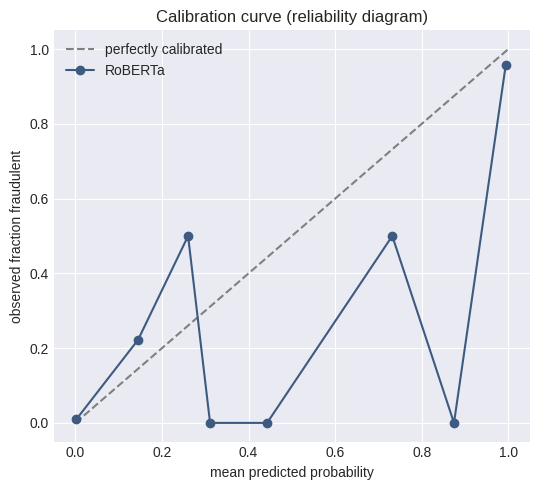

In [70]:
def fn_plot_reliability_diagram(labels, probs, n_bins=10):
    fraction_of_positives, mean_predicted_value = calibration_curve(labels, probs, n_bins=n_bins, strategy="uniform")

    plt.figure(figsize=(5.5, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfectly calibrated")
    plt.plot(mean_predicted_value, fraction_of_positives, marker="o", color="#3d5a80", label="RoBERTa")
    plt.title("Calibration curve (reliability diagram)")
    plt.xlabel("mean predicted probability")
    plt.ylabel("observed fraction fraudulent")
    plt.legend()
    plt.tight_layout()
    plt.show()


fn_plot_reliability_diagram(roberta_test_labels, roberta_test_probs)

## Prediction Confidence

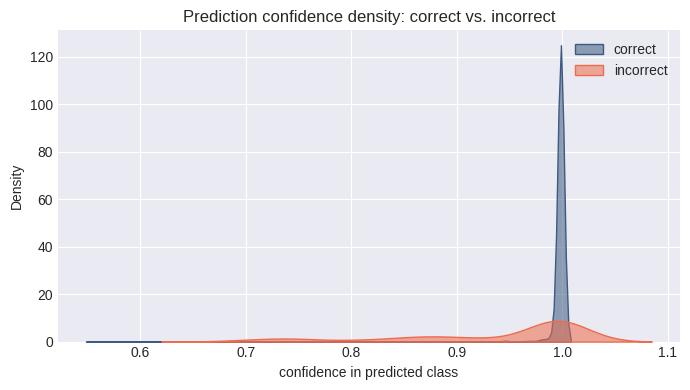

Mean confidence | correct   : 0.9962
Mean confidence | incorrect : 0.9359


In [71]:
def fn_plot_confidence_ridgeline(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    confidence = np.where(preds == 1, probs, 1 - probs)  # distance toward the predicted class
    correct_mask = preds == labels

    plt.figure(figsize=(7, 4))
    sns.kdeplot(confidence[correct_mask], fill=True, color="#3d5a80", alpha=0.55, label="correct", bw_adjust=0.6)
    sns.kdeplot(confidence[~correct_mask], fill=True, color="#ee6c4d", alpha=0.55, label="incorrect", bw_adjust=0.6)
    plt.title("Prediction confidence density: correct vs. incorrect")
    plt.xlabel("confidence in predicted class")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Mean confidence | correct   : {confidence[correct_mask].mean():.4f}")
    print(f"Mean confidence | incorrect : {confidence[~correct_mask].mean():.4f}")


fn_plot_confidence_ridgeline(roberta_test_labels, roberta_test_probs)

## Failure Case Analysis

In [72]:
def fn_build_failure_table(df_test, labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    table = pd.DataFrame({
        "clean_text": df_test["clean_text"].values,
        "true_label": labels,
        "predicted_label": preds,
        "fraud_probability": probs,
    })
    table["text_snippet"] = table["clean_text"].str.slice(0, 160)
    false_negatives = table[(table.true_label == 1) & (table.predicted_label == 0)].sort_values("fraud_probability")
    false_positives = table[(table.true_label == 0) & (table.predicted_label == 1)].sort_values("fraud_probability", ascending=False)
    return false_negatives, false_positives

In [73]:
false_negatives_df, false_positives_df = fn_build_failure_table(test_split, roberta_test_labels, roberta_test_probs)

In [74]:
print(f"False negatives (missed fraud): {len(false_negatives_df)}")
display(false_negatives_df[["text_snippet", "fraud_probability"]].head(5))

False negatives (missed fraud): 19


,text_snippet,fraud_probability
127,android developer infullmobile sp. z o.o. is a...,0.000924
760,bilingual retail demonstrator dyson demonstrat...,0.001003
1313,front-end developer rideamigos needs a great f...,0.001033
589,offshore construction superintendent expro is ...,0.001355
544,senior javascript developer rideamigos is hiri...,0.001563


In [75]:
print(f"\nFalse positives (genuine flagged as fraud): {len(false_positives_df)}")
display(false_positives_df[["text_snippet", "fraud_probability"]].head(5))


False positives (genuine flagged as fraud): 8


,text_snippet,fraud_probability
1721,payroll clerk $20/hr the accounting clerk will...,0.998296
1414,project manager we are looking for a project m...,0.991462
1514,office assistant we have an opening for a ener...,0.986535
963,food & beverage assistant ( waitress / waiter ...,0.883978
1723,bookkeeper/office manager responsible for all ...,0.881435


## Model Export

In [76]:
export_dir = JOB_CFG["runtime"]["artifact_dir"]

roberta_export_dir = os.path.join(export_dir, "roberta_fraud_detector")
os.makedirs(roberta_export_dir, exist_ok=True)
job_model.save_pretrained(roberta_export_dir)
job_tokenizer.save_pretrained(roberta_export_dir)
with open(os.path.join(roberta_export_dir, "job_cfg.json"), "w") as fh:
    json.dump(JOB_CFG, fh, indent=2)

joblib.dump(
    {"vectorizer": nb_vectorizer, "classifier": nb_classifier},
    os.path.join(export_dir, "naive_bayes_baseline.joblib"),
)

print(f"RoBERTa artefacts  -> {roberta_export_dir}")
print(f"Naive Bayes bundle -> {os.path.join(export_dir, 'naive_bayes_baseline.joblib')}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa artefacts  -> job_fraud_artifacts/roberta_fraud_detector
Naive Bayes bundle -> job_fraud_artifacts/naive_bayes_baseline.joblib


## Interactive Prediction

In [77]:
def fn_predict_job_posting(field_dict, model, tokenizer, cfg):
    '''
    field_dict: e.g. {"title": "...", "company_profile": "...", "description": "...",
                       "requirements": "...", "benefits": "..."}
    Returns a dict with the predicted label and both class probabilities.
    '''
    joined = " ".join(str(field_dict.get(f, "")) for f in cfg["data"]["text_fields"])
    cleaned = CLEAN_TEXT_PIPELINE(joined)
    encoded = tokenizer(cleaned, truncation=True, max_length=TOKEN_BUDGET, return_tensors="pt").to(cfg["runtime"]["device"])
    with torch.no_grad():
        probs = F.softmax(model(**encoded).logits, dim=-1).cpu().numpy()[0]
    verdict = "FRAUDULENT" if probs[1] >= 0.5 else "genuine"
    return {"verdict": verdict, "prob_genuine": float(probs[0]), "prob_fraudulent": float(probs[1])}

In [78]:
_demo_examples = [
    {"title": "Data Entry Clerk - Work From Home",
     "description": "Earn $5000/week! No experience needed. Send your bank details to get started immediately."},
    {"title": "Backend Software Engineer",
     "company_profile": "We are a mid-size fintech company based in Berlin.",
     "description": "You will design and maintain REST APIs in Python, collaborate with the platform team, "
                     "and participate in code review.",
     "requirements": "3+ years experience with Python, SQL, and distributed systems."},
]
for example in _demo_examples:
    result = fn_predict_job_posting(example, job_model, job_tokenizer, JOB_CFG)
    print(example.get("title"), "->", result)

Data Entry Clerk - Work From Home -> {'verdict': 'FRAUDULENT', 'prob_genuine': 0.0013257716782391071, 'prob_fraudulent': 0.9986742734909058}
Backend Software Engineer -> {'verdict': 'genuine', 'prob_genuine': 0.9987926483154297, 'prob_fraudulent': 0.0012072891695424914}
